# Task 2: Data Preprocessing & Feature Engineering

# Objective

The objective of this task is to clean the dataset, handle missing values, create new useful features, standardize numerical columns, and encode categorical variables for better analysis.

In [133]:
# Import libraries

import pandas as pd
import numpy as np

In [134]:
# Load dataset

df = pd.read_csv("bank_employee_attrition.csv")

# Display first 5 records

df.head()

,MMMM_YY,Employee_ID,Age,Gender,City,Education_Level,Department,Income,Date_Of_Joining,LastWorkingDate,Joining_Designation,Grade,Total_Business_Value,Quarterly_Rating,Overtime_Flag
0,Jan-21,10001,29.0,0,BLR,1,Operations,64380.0,17-08-2018,21-08-2021,Analyst,C,11806,2.0,0
1,Feb-21,10001,29.0,0,BLR,1,Operations,64380.0,17-08-2018,21-08-2021,Analyst,C,16644,1.0,0
2,Mar-21,10001,29.0,0,BLR,1,Operations,64380.0,17-08-2018,21-08-2021,Analyst,C,26253,3.0,1
3,Apr-21,10001,29.0,0,BLR,1,Operations,64380.0,17-08-2018,21-08-2021,Analyst,C,-12414,1.0,1
4,May-21,10001,29.0,0,BLR,1,Operations,64380.0,17-08-2018,21-08-2021,Analyst,C,39153,2.0,0


# Handle Missing Values

In [135]:
# Check missing values before treatment

df.isnull().sum()

MMMM_YY                    0
Employee_ID                0
Age                      206
Gender                     0
City                       0
Education_Level            0
Department                 0
Income                   540
Date_Of_Joining            0
LastWorkingDate         9288
Joining_Designation        0
Grade                      0
Total_Business_Value       0
Quarterly_Rating         335
Overtime_Flag              0
dtype: int64

# Age Imputation

In [136]:
# Fill missing Age values using median

df['Age'] = df['Age'].fillna(df['Age'].median())

In [137]:
# Check missing values in Age

df['Age'].isnull().sum()

np.int64(0)

# Income Imputation

In [138]:
# Fill missing Income values using Department-wise mean

df['Income'] = df['Income'].fillna(
    df.groupby('Department')['Income'].transform('mean')
)

In [139]:
# Verify missing values in Income

df['Income'].isnull().sum()

np.int64(0)

# Quarterly Rating Imputation

In [140]:
# Fill missing Quarterly Rating using mode

rating_mode = df['Quarterly_Rating'].mode()[0]

df['Quarterly_Rating'] = df['Quarterly_Rating'].fillna(rating_mode)

In [141]:
# Verify missing values in Quarterly Rating

df['Quarterly_Rating'].isnull().sum()

np.int64(0)

# Last Working Date

In [142]:
# LastWorkingDate will not be imputed

# Null values indicate employee is still active

df['LastWorkingDate'].isnull().sum()

np.int64(9288)

# Feature Engineering

# Convert Date Columns

In [143]:
# Convert date columns into datetime format

df['MMMM_YY'] = pd.to_datetime(df['MMMM_YY'], format='%b-%y')

df['Date_Of_Joining'] = pd.to_datetime(df['Date_Of_Joining'], errors='coerce')

df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'], errors='coerce')

C:\Users\Muneeza\AppData\Local\Temp\ipykernel_23544\4201176113.py:5: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date_Of_Joining'] = pd.to_datetime(df['Date_Of_Joining'], errors='coerce')
C:\Users\Muneeza\AppData\Local\Temp\ipykernel_23544\4201176113.py:7: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'], errors='coerce')


# Create Attrition Column

In [144]:
# Create Attrition flag

df['Attrition'] = np.where(
    df['LastWorkingDate'].notnull(),
    1,
    0
)

In [145]:
# Check attrition distribution

df['Attrition'].value_counts()

Attrition
0    9288
1    1528
Name: count, dtype: int64

# Create Tenure Months

In [146]:
# Convert Date_Of_Joining to datetime

df['Date_Of_Joining'] = pd.to_datetime(
    df['Date_Of_Joining'],
    dayfirst=True
)

# Convert LastWorkingDate to datetime

df['LastWorkingDate'] = pd.to_datetime(
    df['LastWorkingDate'],
    dayfirst=True
)

In [147]:
# Check data types

df[['MMMM_YY','Date_Of_Joining']].dtypes

MMMM_YY            datetime64[ns]
Date_Of_Joining    datetime64[ns]
dtype: object

In [148]:
# Create Tenure Months

df['Tenure_Months'] = (
    (df['MMMM_YY'].dt.year - df['Date_Of_Joining'].dt.year) * 12
    +
    (df['MMMM_YY'].dt.month - df['Date_Of_Joining'].dt.month)
)

# View first 5 values

df[['Tenure_Months']].head()

,Tenure_Months
0,29
1,30
2,31
3,32
4,33


In [149]:
# Fill missing Total_Business_Value

median_value = df['Total_Business_Value'].median()

df['Total_Business_Value'] = np.where(
    (df['Total_Business_Value'].isnull()) &
    (df['Tenure_Months'] < 3),
    0,
    df['Total_Business_Value']
)

df['Total_Business_Value'] = df['Total_Business_Value'].fillna(median_value)

# Verify missing values

df['Total_Business_Value'].isnull().sum()

np.int64(0)

# Create Age At Joining

In [150]:
# Calculate age at joining

df['Age_At_Joining'] = (
    df['Age'] - (df['Tenure_Months']/12)
)

# Rating Increased Flag

In [151]:
# Sort values before comparison

df = df.sort_values(
    ['Employee_ID','MMMM_YY']
)

# Create Rating Increased flag

prev_rating = df.groupby('Employee_ID')['Quarterly_Rating'].shift(1)

df['Rating_Increased'] = np.where(
    df['Quarterly_Rating'] > prev_rating,
    1,
    0
)

In [152]:
# Check distribution of Rating_Increased flag

df['Rating_Increased'].value_counts()

Rating_Increased
0    7247
1    3569
Name: count, dtype: int64

# Income Increased Flag

In [153]:
# Create Income Increased flag

prev_income = df.groupby('Employee_ID')['Income'].shift(1)

df['Income_Increased'] = np.where(
    df['Income'] > prev_income,
    1,
    0
)

In [154]:
# Check distribution of Income_Increased flag

df['Income_Increased'].value_counts()

Income_Increased
0    10173
1      643
Name: count, dtype: int64

# Grade Change Flag

In [155]:
# Identify promotion or grade change

joining_grade = df.groupby('Employee_ID')['Grade'].transform('first')

df['Grade_Change'] = np.where(
    df['Grade'] != joining_grade,
    1,
    0
)

In [156]:
# Check distribution of Grade_Change flag

df['Grade_Change'].value_counts()

Grade_Change
0    9976
1     840
Name: count, dtype: int64

# Overtime Ratio

In [157]:
# Calculate overtime ratio

overtime_count = df.groupby('Employee_ID')['Overtime_Flag'].transform('sum')

df['Overtime_Ratio'] = overtime_count / (df['Tenure_Months'] + 1)

In [158]:
df['Overtime_Ratio'].head()

0    0.133333
1    0.129032
2    0.125000
3    0.121212
4    0.117647
Name: Overtime_Ratio, dtype: float64

# Class Imbalance Check

In [159]:
# Check attrition distribution

df['Attrition'].value_counts()

Attrition
0    9288
1    1528
Name: count, dtype: int64

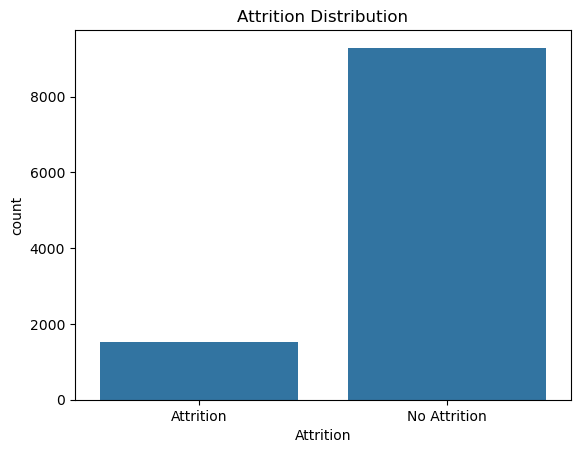

In [160]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['Attrition'].replace({0:'No Attrition', 1:'Attrition'}))

plt.title("Attrition Distribution")

plt.show()

# Insights

- Most employees belong to the No Attrition category, indicating a high employee retention rate.
- Employees who left the organization (Attrition) represent a relatively small portion of the workforce.
- The dataset shows a clear class imbalance, with significantly more retained employees than employees who left.

# Standardization

In [161]:
# Standardize Age

df['Age_scaled'] = (
    (df['Age'] - df['Age'].mean())
    /
    df['Age'].std()
)

In [162]:
# Standardize Income

df['Income_scaled'] = (
    (df['Income'] - df['Income'].mean())
    /
    df['Income'].std()
)

In [163]:
# Standardize Tenure Months

df['Tenure_Months_scaled'] = (
    (df['Tenure_Months'] - df['Tenure_Months'].mean())
    /
    df['Tenure_Months'].std()
)

In [164]:
# Standardize Total Business Value

df['Total_Business_Value_scaled'] = (
    (df['Total_Business_Value']
     - df['Total_Business_Value'].mean())
    /
    df['Total_Business_Value'].std()
)

In [165]:
# Check scaled columns

df[['Age_scaled',
    'Income_scaled',
    'Tenure_Months_scaled',
    'Total_Business_Value_scaled']].head()

,Age_scaled,Income_scaled,Tenure_Months_scaled,Total_Business_Value_scaled
0,-1.002295,0.511239,0.156344,-0.922360
1,-1.002295,0.511239,0.228211,-0.844770
2,-1.002295,0.511239,0.300077,-0.690665
3,-1.002295,0.511239,0.371944,-1.310790
4,-1.002295,0.511239,0.443810,-0.483780


# Encoding Categorical Variables

In [166]:
# Encode Grade

df['Grade'] = df['Grade'].map({
    'A': 1,
    'B': 2,
    'C': 3,
    'D': 4,
    'E': 5
})

In [167]:
# Check encoded Grade values

df['Grade'].value_counts()

Grade
3    3924
2    3452
1    3045
4     392
5       3
Name: count, dtype: int64

In [168]:
# Apply One Hot Encoding

df_encoded = pd.get_dummies(
    df,
    columns=[
        'City',
        'Department',
        'Joining_Designation'
    ],
    drop_first=True
)

In [171]:
df_encoded.head()

,MMMM_YY,Employee_ID,Age,Gender,Education_Level,Income,Date_Of_Joining,LastWorkingDate,Grade,Total_Business_Value,...,City_PUN,Department_HR & Admin,Department_IT & Digital,Department_Operations,Department_Retail Banking,Department_Risk & Compliance,Joining_Designation_Associate Manager,Joining_Designation_Deputy Manager,Joining_Designation_Manager,Joining_Designation_Senior Analyst
0,2021-01-01,10001,29.0,0,1,64380.0,2018-08-17,2021-08-21,3,11806,...,False,False,False,True,False,False,False,False,False,False
1,2021-02-01,10001,29.0,0,1,64380.0,2018-08-17,2021-08-21,3,16644,...,False,False,False,True,False,False,False,False,False,False
2,2021-03-01,10001,29.0,0,1,64380.0,2018-08-17,2021-08-21,3,26253,...,False,False,False,True,False,False,False,False,False,False
3,2021-04-01,10001,29.0,0,1,64380.0,2018-08-17,2021-08-21,3,-12414,...,False,False,False,True,False,False,False,False,False,False
4,2021-05-01,10001,29.0,0,1,64380.0,2018-08-17,2021-08-21,3,39153,...,False,False,False,True,False,False,False,False,False,False


# Conclusion

- Missing values were handled successfully using appropriate imputation techniques.
- New features were created to support employee attrition analysis.
- Attrition distribution was examined to understand class imbalance.
- Numerical variables were standardized using Z-score scaling.
- Categorical variables were encoded using ordinal and one-hot encoding methods.